Thrust phase status: 1
Initial Altitude: 500 km
Final Target Altitude: 35000 km
Max Thrust: 1.0 N
Initial speed: 7.613 km/s
Final (thrust cutoff) speed: 3.104 km/s
44.9384 kg of propellant used
Time of flight: 51.0089 days
Number of orbits is: 322
Coast Raidus Percent Error: 0.021 %
Coast eccentricity: 0.00904 km
Speed after coast: 3.091 km/s


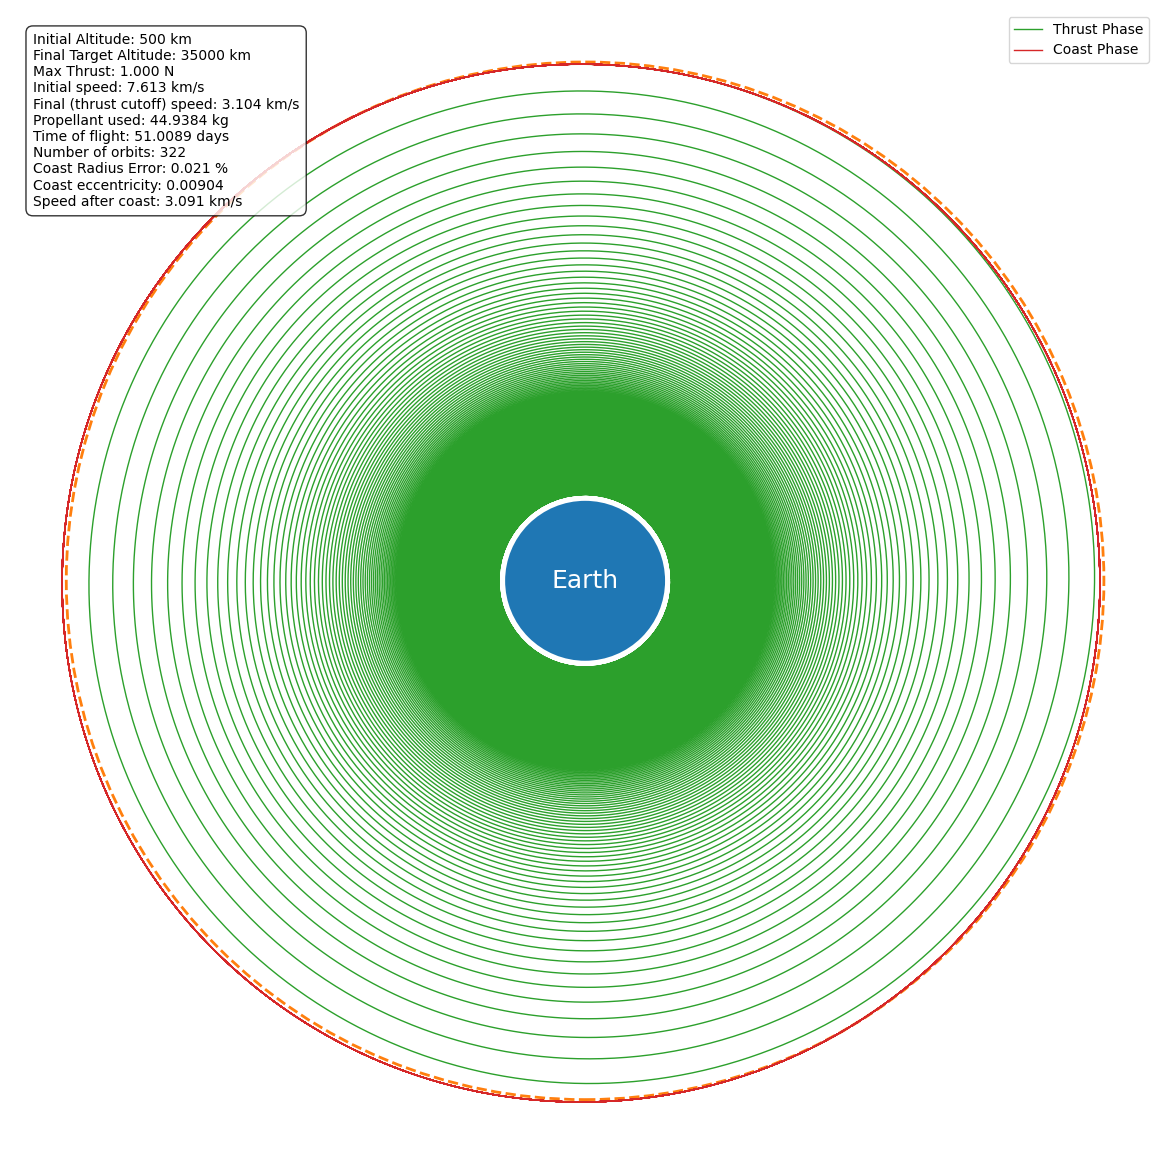

In [2]:
# %matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from scipy.integrate import solve_ivp

# --- Constants ---
R_E = 6378  # km
mu = 3.986e5  # km**3/s**2

a_init = 500 # INPUT, Initial circular ALTITUDE
r_init = a_init + R_E # km
v_init = np.sqrt(mu / r_init)  # km/s

a_final = 35000 # INPUT, Final circular ALTITUDE
r_2 = a_final + R_E  # km

r_0 = np.array((r_init, 0, 0))  # km
v_0 = np.array((0, v_init, 0))  # km/s
m_0 = np.array(1000)  # kg
Y_0 = np.hstack((r_0, v_0, m_0))

# --- Engine parameters ---
T = 1 / 1000  # kN INPUT, Max Thrust of System
I_sp = 10_000  # s
g_0 = 9.807e-3  # km/s**2

# --- Dynamics ---
def nonimpulsive_maneuver(t, Y, mu, T, I_sp, g_0, r_2):
    r = np.sqrt(np.dot(Y[0:3], Y[0:3]))
    v = np.sqrt(np.dot(Y[3:6], Y[3:6]))
    m = Y[-1]

    dY_dt = np.zeros(len(Y))
    dY_dt[0:3] = Y[3:6]
    dY_dt[3:6] = -mu * Y[0:3] / r**3 + T * Y[3:6] / (m * v)
    dY_dt[-1] = -T / (I_sp * g_0)
    return dY_dt

def reached_destination(t, Y, mu, T, I_sp, g_0, r_2):
    r_vec = Y[0:3]
    r = np.sqrt(np.dot(r_vec, r_vec))
    return r - r_2

reached_destination.terminal = True

def mass(t, Y, mu, T, I_sp, g_0, r_2):
    return Y[-1]
mass.terminal = True

def orbit_crossing(t, Y, mu, T, I_sp, g_0, r_2):
    return Y[1]
orbit_crossing.direction = 1

# --- Thrust phase integration ---
t_end = 100_000_000  # s
t_eval = np.linspace(0, t_end, int(1e6))
sol_thrust = solve_ivp(
    nonimpulsive_maneuver,
    t_span=(0, t_end),
    y0=Y_0,
    t_eval=t_eval,
    events=(reached_destination, mass, orbit_crossing),
    rtol=1e-12,
    atol=1e-15,
    method="DOP853",
    args=(mu, T, I_sp, g_0, r_2),
)
print("Thrust phase status:", sol_thrust.status)

# --- Extract final state ---
Y_final_thrust = sol_thrust.y[:, -1]
t_final = sol_thrust.t[-1]

# --- Coast phase (Thrust = 0) ---
def coast_dynamics(t, Y, mu):
    r = np.sqrt(np.dot(Y[0:3], Y[0:3]))
    dY_dt = np.zeros(len(Y))
    dY_dt[0:3] = Y[3:6]
    dY_dt[3:6] = -mu * Y[0:3] / r**3
    dY_dt[-1] = 0  # no more mass flow
    return dY_dt

t_coast = 1209600 # seconds (14 days)

t_coast_end = t_final + t_coast  # propagate for a while longer
sol_coast = solve_ivp(
    coast_dynamics,
    t_span=(t_final, t_coast_end),
    y0=Y_final_thrust,
    t_eval = np.linspace(t_final, t_coast_end, 10000),
    rtol=1e-12,
    atol=1e-15,
    args=(mu,),
)

# t_coast_end = t_final + 315360000  # propagate for a while longer (~10 years)
# sol_coast = solve_ivp(
#     coast_dynamics,
#     t_span=(t_final, t_coast_end),
#     y0=Y_final_thrust,
#     t_eval=np.linspace(t_final, t_coast_end, 86400),
#     rtol=1e-12,
#     atol=1e-15,
#     args=(mu,),
# )

# --- Combine results ---
r_vec_thrust = sol_thrust.y[0:3].T
r_vec_coast = sol_coast.y[0:3].T

r__coast_apo = np.max(np.linalg.norm(r_vec_coast, axis = 1))
r_coast_per = np.min(np.linalg.norm(r_vec_coast, axis = 1))


r_coast_avg = (r_coast_per + r__coast_apo)/2
r_coast_error = (r_coast_avg - r_2)/(r_2) * (100)
e_coast = (r__coast_apo - r_coast_per)/(r__coast_apo + r_coast_per)


r_vec = np.concatenate((r_vec_thrust, r_vec_coast))
v_vec = np.concatenate((sol_thrust.y[3:6].T, sol_coast.y[3:6].T))

# --- Speed info ---
v_init_val = np.sqrt(mu / r_init)
v_final_thrust = np.linalg.norm(sol_thrust.y[3:6][:, -1])
v_final_coast = np.linalg.norm(sol_coast.y[3:6][:, -1])

# -- Terminal Output --
print(f"Initial Altitude: {a_init} km")
print(f"Final Target Altitude: {a_final} km")
print(f"Max Thrust: {T*1000} N")
print(f"Initial speed: {v_init_val:.3f} km/s")
print(f"Final (thrust cutoff) speed: {v_final_thrust:.3f} km/s")
print(f"{m_0 - Y_final_thrust[6]:.4F} kg of propellant used")
print(f"Time of flight: {sol_thrust.t_events[0][0] / (3600 * 24):.4F} days")
print(f"Number of orbits is: {sol_thrust.t_events[2].shape[0]}")
print(f"Coast Raidus Percent Error: {r_coast_error:.3f} %")
print(f"Coast eccentricity: {e_coast:.5f} km")
print(f"Speed after coast: {v_final_coast:.3f} km/s")


# --- Plot orbit ---

summary_text = (
    f"Initial Altitude: {a_init} km\n"
    f"Final Target Altitude: {a_final} km\n"
    f"Max Thrust: {T*1000:.3f} N\n"
    f"Initial speed: {v_init_val:.3f} km/s\n"
    f"Final (thrust cutoff) speed: {v_final_thrust:.3f} km/s\n"
    f"Propellant used: {m_0 - Y_final_thrust[6]:.4f} kg\n"
    f"Time of flight: {sol_thrust.t_events[0][0] / (3600 * 24):.4f} days\n"
    f"Number of orbits: {sol_thrust.t_events[2].shape[0]}\n"
    f"Coast Radius Error: {r_coast_error:.3f} %\n"
    f"Coast eccentricity: {e_coast:.5f}\n"
    f"Speed after coast: {v_final_coast:.3f} km/s"
)

plt.rc("font", size=18)
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_aspect("equal")
ax.axis("off")

# Earth and Altitude marker
ax.add_patch(Circle((0, 0), R_E, ec="none", fc="C0"))
ax.annotate("Earth", xy=(0, 0), ha="center", va="center", color="white")
ax.add_patch(Circle((0, 0), r_2, ec="C1", fc="none", lw=2, ls="--"))

# Orbit trajectory
ax.plot(r_vec_thrust[:, 0], r_vec_thrust[:, 1], color="C2", lw=1, label="Thrust Phase")
ax.plot(r_vec_coast[:, 0], r_vec_coast[:, 1], color="C3", lw=1, label="Coast Phase")

# Labels
ax.legend(loc="upper right", fontsize=10)

ax.text(
    0.02, 0.98,
    summary_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8),
)

plt.show()